In [1]:
# ============================================================
# 自動從 Kaggle 下載 OULAD 資料集
# 首次執行前請確保已設定 Kaggle API Token：
#   執行過一次後資料會存在專案的 data/ 資料夾，下次不需重新下載
# ============================================================

import subprocess, sys, os, shutil

# 安裝 kagglehub（若尚未安裝）
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kagglehub"])

import kagglehub

# 設定下載目標為專案資料夾內的 data/
PROJECT_DIR = os.path.dirname(os.path.abspath('__file__'))
DATA_DIR = os.path.join(PROJECT_DIR, 'data')

# 若 data/ 已存在且有 CSV 檔案，直接使用（跳過下載）
existing_csvs = [f for f in os.listdir(DATA_DIR) if f.endswith('.csv')] if os.path.exists(DATA_DIR) else []

if existing_csvs:
    print(f"✅ 資料已存在於 {DATA_DIR}，跳過下載。")
    dataset_path = DATA_DIR
else:
    print("📥 開始從 Kaggle 下載資料集...")
    # 先下載到系統快取
    cache_path = kagglehub.dataset_download("anlgrbz/student-demographics-online-education-dataoulad")
    print(f"快取路徑: {cache_path}")

    # 複製到專案的 data/ 資料夾
    os.makedirs(DATA_DIR, exist_ok=True)
    for root, dirs, files in os.walk(cache_path):
        for fname in files:
            if fname.endswith('.csv'):
                src = os.path.join(root, fname)
                dst = os.path.join(DATA_DIR, fname)
                shutil.copy2(src, dst)
                print(f"  已複製: {fname}")
    dataset_path = DATA_DIR
    print(f"✅ 所有 CSV 已儲存到: {DATA_DIR}")

# 建立 {檔名: 完整路徑} 字典，供後續 pd.read_csv() 使用
csv_files = {}
for fname in os.listdir(DATA_DIR):
    if fname.endswith('.csv'):
        csv_files[fname] = os.path.join(DATA_DIR, fname)

print("\n找到的 CSV 檔案：")
for k, v in csv_files.items():
    print(f"  {k}")

📥 開始從 Kaggle 下載資料集...
Using Colab cache for faster access to the 'student-demographics-online-education-dataoulad' dataset.
快取路徑: /kaggle/input/student-demographics-online-education-dataoulad
  已複製: studentRegistration.csv
  已複製: studentAssessment.csv
  已複製: studentInfo.csv
  已複製: studentVle.csv
  已複製: vle.csv
  已複製: assessments.csv
  已複製: courses.csv
✅ 所有 CSV 已儲存到: /content/data

找到的 CSV 檔案：
  courses.csv
  studentAssessment.csv
  vle.csv
  studentRegistration.csv
  studentVle.csv
  assessments.csv
  studentInfo.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pickle

In [3]:
stVLE = pd.read_csv(csv_files['studentVle.csv'])

In [4]:
# only use the data from the course start
stVLE_update = stVLE[stVLE['date']>=0]

In [5]:
stAss = pd.read_csv(csv_files['studentAssessment.csv'])
stReg = pd.read_csv(csv_files['studentRegistration.csv'])
stInfo = pd.read_csv(csv_files['studentInfo.csv'])
VLE = pd.read_csv(csv_files['vle.csv'])

In [6]:
# extract pass, disctinctio and fail students
stInfo_update = stInfo[(stInfo['final_result'] =='Pass') | (stInfo['final_result'] =='Distinction')
                       | (stInfo['final_result'] =='Fail')] 

In [7]:
courses = stInfo_update['code_module'].unique()
dic_site_acitivity = {v:k for v, k in zip(VLE['id_site'], VLE['activity_type'])}
actions_len = len(VLE['activity_type'].unique())

actions_dic = VLE['activity_type'].unique().tolist()

actions_dic = {v: k for k, v in enumerate(actions_dic)}

dic_acitivity_idx = {v:k for v, k in actions_dic.items()}

print(dic_acitivity_idx)

{'resource': 0, 'oucontent': 1, 'url': 2, 'homepage': 3, 'subpage': 4, 'glossary': 5, 'forumng': 6, 'oucollaborate': 7, 'dataplus': 8, 'quiz': 9, 'ouelluminate': 10, 'sharedsubpage': 11, 'questionnaire': 12, 'page': 13, 'externalquiz': 14, 'ouwiki': 15, 'dualpane': 16, 'repeatactivity': 17, 'folder': 18, 'htmlactivity': 19}


In [ ]:
# extract features for the course FFF, 2013 as the training and 2014 as the test

from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()

labelencoder.fit(["Distinction", "Fail", "Pass"])

courses = ['FFF'] # we can also add AAA, BBB, CCC

for i, course in enumerate(courses):
    
    stVLE_subset = stVLE_update[stVLE_update['code_module'] == course]
    stInfo_update_filtered = stInfo_update[stInfo_update['code_module'] == course]
    
    # filter multiple attemps
    stInfo_update_filtered.drop_duplicates(subset=['id_student'], keep=False, inplace=True)
    
    stVLE_subset_filtered = stVLE_subset[stVLE_subset['id_student'].isin(stInfo_update_filtered['id_student'])]
    
    stInfo_update_filtered = stInfo_update_filtered[stInfo_update_filtered['id_student'].isin(stVLE_subset_filtered['id_student'])]
    
    
    stVLE_subset_train = stVLE_subset_filtered[(stVLE_subset_filtered['code_presentation'] == '2013B') | 
                                              (stVLE_subset_filtered['code_presentation'] == '2013J')]

    stVLE_subset_test = stVLE_subset_filtered[(stVLE_subset_filtered['code_presentation'] == '2014B') | 
                                              (stVLE_subset_filtered['code_presentation'] == '2014J')]
  
    stinfo_train = stInfo_update_filtered[stInfo_update_filtered['id_student'].isin(stVLE_subset_train['id_student'])]

    stinfo_test = stInfo_update_filtered[stInfo_update_filtered['id_student'].isin(stVLE_subset_test['id_student'])]

    
    studentno_train = len(stVLE_subset_train['id_student'].unique())
    
     
    stinfo_train['arrayIdx'] = np.arange(studentno_train)
    
     
    print('the number of students {} in train course {}'.format(studentno_train, course))
    
    cc = stVLE_subset_train.replace({'id_site': dic_site_acitivity}, inplace=False) 
    stVLE_subset_train['activity_type'] = cc['id_site']
    
    cc = stVLE_subset_train.replace({'activity_type': dic_acitivity_idx}, inplace=False) 
    stVLE_subset_train['activity_idx'] = cc['activity_type']
   
    
    stVLE_subset_train = pd.merge(stVLE_subset_train, stinfo_train[['arrayIdx', 'id_student']], on='id_student', validate='m:1')
    
    total_days = np.max(stVLE_subset_train['date'].values) + 1
    
    # 【升級：3D 時序對齊 - 加入成績維度】
    # 特徵數量從原本的 VLE 點擊類別數 (actions_len) 加 1，最後一個維度 (-1) 用來放「當天評量分數」
    actionArray_train = np.zeros([studentno_train, total_days, actions_len + 1])
    
    y_train = np.zeros(studentno_train)
         
    y_train = labelencoder.transform(stinfo_train['final_result'])
   

    for day in range(total_days):
        
        #print('running the course {} and the day : {}'.format(course, day))
        
        stVLE_days = stVLE_subset_train[stVLE_subset_train['date'] == day]
    
        yy = stVLE_days.groupby(['arrayIdx', 'activity_idx'])['sum_click'].sum().unstack(fill_value=0)

        newyy = yy.reindex(np.arange(actions_len), axis=1, fill_value=0)

        newzz = newyy.reindex(np.arange(studentno_train), axis=0, fill_value=0)

        newzz = newzz.values

        # 前面的維度放點擊次數
        actionArray_train[:,day,:-1] = newzz
        
    # 處理平時測驗成績 (Train)
    stAss_train = stAss[stAss['id_student'].isin(stinfo_train['id_student'])]
    stAss_train = pd.merge(stAss_train, stinfo_train[['arrayIdx', 'id_student']], on='id_student')
    stAss_train = stAss_train[(stAss_train['date_submitted'] >= 0) & (stAss_train['date_submitted'] < total_days)]
    # 【Bug Fix】填補可能出現的 NaN 空缺成績為 0，避免神經網路拿到 NaN 導致 Loss 爆炸
    stAss_train['score'] = stAss_train['score'].fillna(0)
    ass_scores_train = stAss_train.groupby(['arrayIdx', 'date_submitted'])['score'].mean().reset_index()
    for _, row in ass_scores_train.iterrows():
        actionArray_train[int(row['arrayIdx']), int(row['date_submitted']), -1] = row['score']
        
    ####
    
    studentno_test = len(stVLE_subset_test['id_student'].unique())
    
     
    stinfo_test['arrayIdx'] = np.arange(studentno_test)
    
     
    print('the number of students {} in test course {}'.format(studentno_test, course))
    
    cc = stVLE_subset_test.replace({'id_site': dic_site_acitivity}, inplace=False) 
    stVLE_subset_test['activity_type'] = cc['id_site']
    
    cc = stVLE_subset_test.replace({'activity_type': dic_acitivity_idx}, inplace=False) 
    stVLE_subset_test['activity_idx'] = cc['activity_type']
   
    
    stVLE_subset_test = pd.merge(stVLE_subset_test, stinfo_test[['arrayIdx', 'id_student']], on='id_student', validate='m:1')
    
    total_days = np.max(stVLE_subset_test['date'].values) + 1
    
    # 【升級：3D 時序對齊 - 加入成績維度】
    actionArray_test= np.zeros([studentno_test, total_days, actions_len + 1])
    
    y_test = np.zeros(studentno_test)
         
    y_test = labelencoder.transform(stinfo_test['final_result'])
   
    
    for day in range(total_days):
        
        #print('running the course {} and the day : {}'.format(course, day))
        
        stVLE_days = stVLE_subset_test[stVLE_subset_test['date'] == day]
    
        yy = stVLE_days.groupby(['arrayIdx', 'activity_idx'])['sum_click'].sum().unstack(fill_value=0)

        newyy = yy.reindex(np.arange(actions_len), axis=1, fill_value=0)

        newzz = newyy.reindex(np.arange(studentno_test), axis=0, fill_value=0)

        newzz = newzz.values

        # 前面的維度放點擊次數
        actionArray_test[:,day,:-1] = newzz
        
    # 處理平時測驗成績 (Test)
    stAss_test = stAss[stAss['id_student'].isin(stinfo_test['id_student'])]
    stAss_test = pd.merge(stAss_test, stinfo_test[['arrayIdx', 'id_student']], on='id_student')
    stAss_test = stAss_test[(stAss_test['date_submitted'] >= 0) & (stAss_test['date_submitted'] < total_days)]
    # 【Bug Fix】填補可能出現的 NaN 空缺成績為 0
    stAss_test['score'] = stAss_test['score'].fillna(0)
    ass_scores_test = stAss_test.groupby(['arrayIdx', 'date_submitted'])['score'].mean().reset_index()
    for _, row in ass_scores_test.iterrows():
        actionArray_test[int(row['arrayIdx']), int(row['date_submitted']), -1] = row['score']

/tmp/ipykernel_2354/1849333377.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stInfo_update_filtered.drop_duplicates(subset=['id_student'], keep=False, inplace=True)
/tmp/ipykernel_2354/1849333377.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stinfo_train['arrayIdx'] = np.arange(studentno_train)


the number of students 2870 in train course FFF


/tmp/ipykernel_2354/1849333377.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stVLE_subset_train['activity_type'] = cc['id_site']
/tmp/ipykernel_2354/1849333377.py:45: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cc = stVLE_subset_train.replace({'activity_type': dic_acitivity_idx}, inplace=False)
/tmp/ipykernel_2354/1849333377.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documenta

the number of students 2501 in test course FFF


/tmp/ipykernel_2354/1849333377.py:98: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stVLE_subset_test['activity_type'] = cc['id_site']
/tmp/ipykernel_2354/1849333377.py:100: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cc = stVLE_subset_test.replace({'activity_type': dic_acitivity_idx}, inplace=False)
/tmp/ipykernel_2354/1849333377.py:101: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documenta

In [9]:
# import pickle
# with open("saved_click_data_FFF.pkl", "wb") as fp:   #Pickling
#     pickle.dump(savedata, fp)

In [10]:
# merge Distinction and pass
y_train[y_train==2] = 0
y_test[y_test==2] = 0

In [11]:
# print the number of positive and negative samples

[a, b] = np.unique(y_train, return_counts=True)
print(a)
print(b)

[a, b] = np.unique(y_test, return_counts=True)
print(a)
print(b)

[0 1]
[1918  952]
[0 1]
[1759  742]


In [12]:
total_weeks = 37

usedweeks = 10  # the weeks' data we used for prediction, e.g 5, 10, 15, 35 etc

X = list()

for i in range(total_weeks):
    seq_x = np.sum(actionArray_train[:, (7*i):(7*i+6), :], axis=1)
    X.append(seq_x)
X = np.array(X)

actionWeeks = np.swapaxes(X, 0, 1)

def prepare_data(actionWeeks, weeks=1):
    return actionWeeks[:,:weeks,:]

X_train = prepare_data(actionWeeks, weeks=usedweeks)


In [13]:
# scale the training and test data by the log transformation

X = list()

for i in range(total_weeks):
    seq_x = np.sum(actionArray_test[:, (7*i):(7*i+6), :], axis=1)
    X.append(seq_x)
X = np.array(X)

actionWeeks = np.swapaxes(X, 0, 1)

def prepare_data(actionWeeks, weeks=1):
    return actionWeeks[:,:weeks,:]

X_test = prepare_data(actionWeeks, weeks=usedweeks)

from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

XX = np.reshape(X_train, (X_train.shape[0]*X_train.shape[1], X_train.shape[2]))
scaler.fit(np.log(XX + 1))
XX = scaler.transform(np.log(XX+1))

X_train = np.reshape(XX, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
# Ensure data is float32 to prevent TensorFlow format conversion bottlenecks
X_train = X_train.astype(np.float32)
y_train = y_train.astype(np.float32)

XX_test = np.reshape(X_test, (X_test.shape[0]*X_test.shape[1], X_test.shape[2]))
XX_test = scaler.transform(np.log(XX_test+1))
X_test = np.reshape(XX_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))
# Ensure data is float32 to prevent TensorFlow format conversion bottlenecks
X_test = X_test.astype(np.float32)
y_test = y_test.astype(np.float32)

# ==============================================================
# Method 2: 加入靜態資料特徵工程 (Feature Engineering)
# ==============================================================
# 提取相關背景資訊：將性別、最高學位、貧富指標、年齡、修課學分、嘗試次數、殘疾等特徵加入預測
features_to_use = ['gender', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability']

stinfo_train_copy = stinfo_train.copy()
stinfo_test_copy = stinfo_test.copy()

stinfo_train_copy['is_train'] = 1
stinfo_test_copy['is_train'] = 0

# 將 train 和 test 合併以確保 One-Hot Encoding 的維度/種類完全一致
combined_info = pd.concat([stinfo_train_copy, stinfo_test_copy], axis=0)
combined_static = pd.get_dummies(combined_info[features_to_use], drop_first=True)
combined_static.fillna(0, inplace=True)

# 重新分離為 Train 與 Test，且必須依靠 `arrayIdx` 排序，來對齊 X_train, X_test 的順序
X_train_static_df = combined_static[combined_info['is_train'] == 1].copy()
X_train_static_df['arrayIdx'] = stinfo_train_copy['arrayIdx'].values
X_train_static_df = X_train_static_df.sort_values('arrayIdx').drop('arrayIdx', axis=1)

X_test_static_df = combined_static[combined_info['is_train'] == 0].copy()
X_test_static_df['arrayIdx'] = stinfo_test_copy['arrayIdx'].values
X_test_static_df = X_test_static_df.sort_values('arrayIdx').drop('arrayIdx', axis=1)

from sklearn.preprocessing import StandardScaler
static_scaler = StandardScaler()
X_train_static = static_scaler.fit_transform(X_train_static_df.values).astype(np.float32)
X_test_static = static_scaler.transform(X_test_static_df.values).astype(np.float32)

print("\nX_train_static shape: ", X_train_static.shape)
print("X_test_static shape: ", X_test_static.shape)


X_train_static shape:  (2870, 19)
X_test_static shape:  (2501, 19)


In [14]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Embedding, LSTM, BatchNormalization, Bidirectional, LayerNormalization
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from keras import regularizers
import re
from keras.layers import Dropout

In [15]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    # 依照建議：再次改回監控 val_auc，並將 patience 設為 15，mode 設為 max
    monitor='val_auc', 
    verbose=1,
    patience=15, 
    mode='max',  
    restore_best_weights=True)

METRICS = [
    # 上一步已經修復過這個 Bug！現在確定是 BinaryAccuracy
    keras.metrics.BinaryAccuracy(name='accuracy'),
    keras.metrics.Recall(name='recall'),
    keras.metrics.Precision(name='precision'),
    keras.metrics.AUC(name='auc')
]


n_steps = X_train.shape[1]
n_features = X_train.shape[2]

In [16]:
tf.keras.backend.clear_session()
tf.compat.v1.reset_default_graph()

import tensorflow.keras.backend as K
from tensorflow.keras.layers import Input, Dense, LSTM, Bidirectional, Concatenate, Multiply, Softmax, Lambda, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers

# ==============================================================
# Method 1: 實作 Focal Loss 損失函數
# 降低 Safe(數量大易分) 的權重，強迫專注 Risky 與邊界難分的樣本
# ==============================================================
def binary_focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, K.epsilon(), 1.0 - K.epsilon())
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_factor = y_true * alpha + (1 - y_true) * (1 - alpha)
        modulating_factor = tf.pow(1.0 - p_t, gamma)
        loss = -alpha_factor * modulating_factor * tf.math.log(p_t)
        return tf.reduce_mean(loss)
    return focal_loss_fn

n_steps = X_train.shape[1]
n_features = X_train.shape[2]
n_static_features = X_train_static.shape[1]

# ==============================================================
# Method 3: 結合 LSTM + Attention + 靜態特徵的 Multi-Input 架構
# ==============================================================
# [分支 A：時序點擊資料]
input_seq = Input(shape=(n_steps, n_features), name='seq_input')
# 注意這裡 return_sequences=True 以便將每個 step 的輸出傳給 Attention
lstm_out = Bidirectional(LSTM(128, return_sequences=True, 
                              dropout=0.1, recurrent_dropout=0.1,
                              kernel_regularizer=regularizers.l2(0.0005)))(input_seq)

# [分支 B：注意力機制 (Attention)]
attention_scores = Dense(1, activation='tanh')(lstm_out)
attention_weights = Softmax(axis=1, name='attention_weights')(attention_scores)
context_vector = Multiply()([lstm_out, attention_weights])
context_vector = Lambda(lambda x: tf.reduce_sum(x, axis=1), name='context_vector')(context_vector) # 把 time steps 總和壓縮成單一向量

# [分支 C：靜態學生背景資料]
input_static = Input(shape=(n_static_features,), name='static_input')

# [合併所有特徵 (Method 2)]
merged = Concatenate(name='concat_features')([context_vector, input_static])

# [分類器結構]
x = Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.0005))(merged)
x = Dropout(0.2)(x)
output = Dense(1, activation='sigmoid', name='final_output')(x)

model = Model(inputs=[input_seq, input_static], outputs=output)

# 編譯使用 Focal Loss
model.compile(loss=binary_focal_loss(gamma=2.0, alpha=0.5), 
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
              metrics=METRICS)

print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 10, 21)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 10, 256)   │    153,600 │ seq_input[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 10, 1)     │        257 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_weights   │ (None, 10, 1)     │          0 │ dense[0][0]       │
│ (Softmax)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 10, 256)   │          0 │ bidirectional[0]… │
│                     │                   │            │ attention_weight… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context_vector      │ (None, 256)       │          0 │ multiply[0][0]    │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_input        │ (None, 19)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_features     │ (None, 275)       │          0 │ context_vector[0… │
│ (Concatenate)       │                   │            │ static_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │     17,664 │ concat_features[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ final_output        │ (None, 1)         │         65 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 171,586 (670.26 KB)

 Trainable params: 171,586 (670.26 KB)

 Non-trainable params: 0 (0.00 B)

None


In [17]:
# 【優化改動】: 將 batch_size 縮小為 64，可以讓模型更新權重的顆粒度更細膩，容易收斂到更好的谷底
batch_size = 64 
my_callbacks = [early_stopping]

neg = len(y_train[y_train ==0])
pos = len(y_train[y_train ==1])
total = neg + pos
weight_for_0 = (1 / neg)*(total)/2.0 
weight_for_1 = (1 / pos)*(total)/2.0

class_weight = {0: weight_for_0, 1: weight_for_1}

# 傳入 LSTM 的時距資料 [X_train] 與 靜態背景資料 [X_train_static] 作為 inputs
history = model.fit([X_train, X_train_static], y_train, epochs=100, batch_size=batch_size, 
                    validation_data=([X_test, X_test_static], y_test), 
                    callbacks=my_callbacks, class_weight=class_weight,
                    verbose=2, shuffle=True)

Epoch 1/100
45/45 - 14s - 315ms/step - accuracy: 0.6693 - auc: 0.1493 - loss: nan - precision: 0.5046 - recall: 0.1712 - val_accuracy: 0.7033 - val_auc: 0.0000e+00 - val_loss: nan - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/100
45/45 - 3s - 65ms/step - accuracy: 0.6683 - auc: 0.0000e+00 - loss: nan - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.7033 - val_auc: 0.0000e+00 - val_loss: nan - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/100
45/45 - 3s - 60ms/step - accuracy: 0.6683 - auc: 0.0000e+00 - loss: nan - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.7033 - val_auc: 0.0000e+00 - val_loss: nan - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/100
45/45 - 5s - 115ms/step - accuracy: 0.6683 - auc: 0.0000e+00 - loss: nan - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.7033 - val_auc: 0.0000e+00 - val_loss: nan - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/100
45/45 - 3s - 65ms/step - 

KeyboardInterrupt: 

In [24]:
results = model.evaluate([X_test, X_test_static], y_test)

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7949 - auc: 0.8302 - loss: 0.0610 - precision: 0.7495 - recall: 0.4636


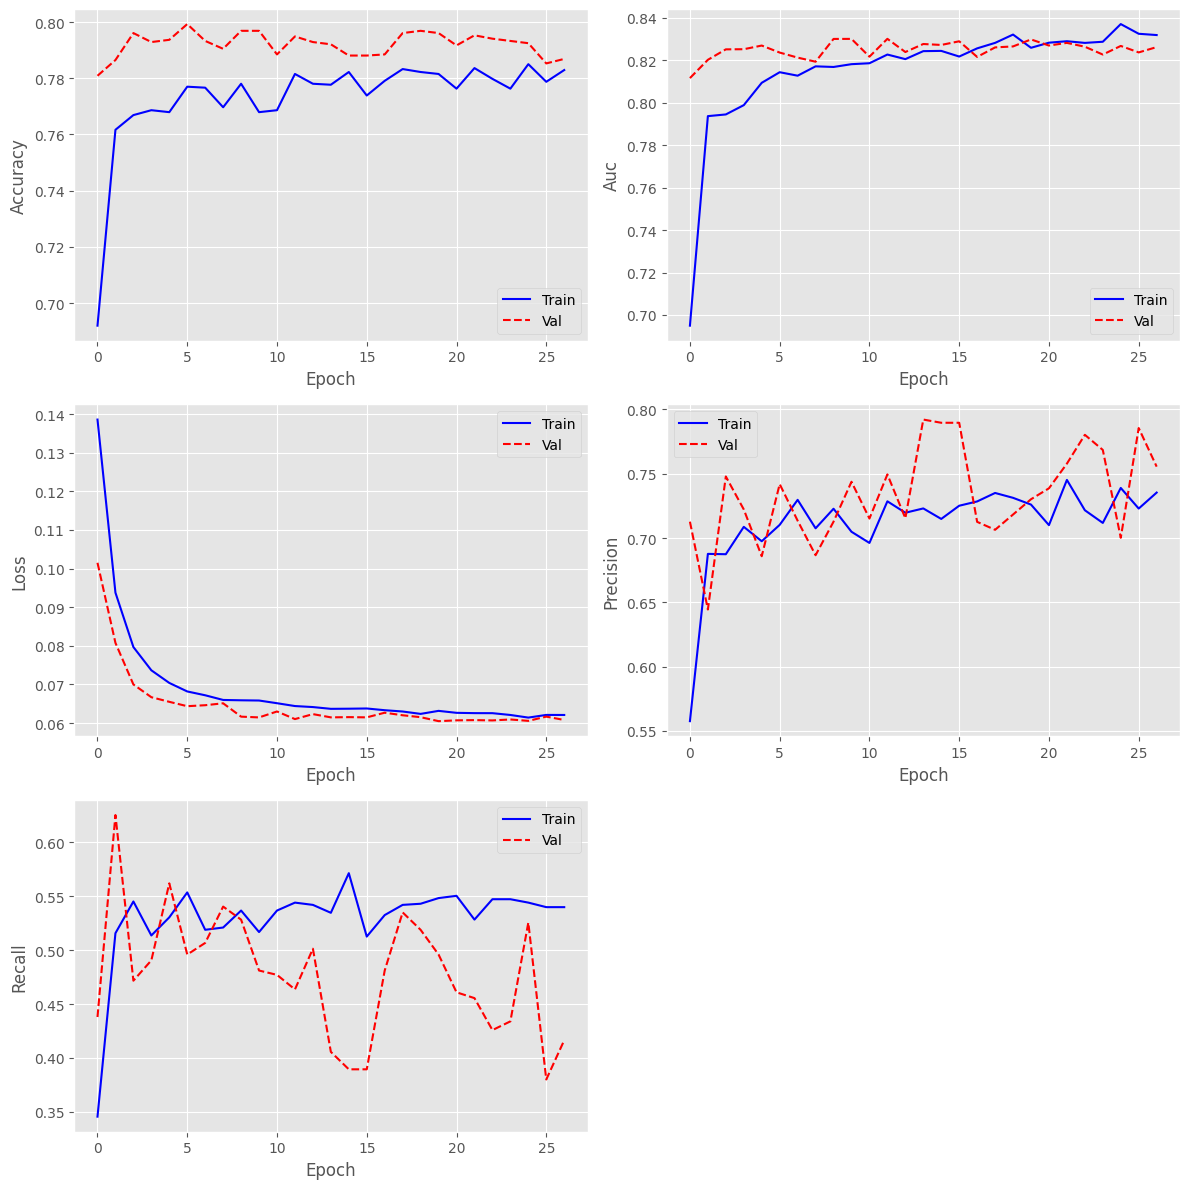

90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

🔥 [自動最佳化] 演算法計算出能達到最高 F1-score 的最佳 Threshold 為: 0.4289
Confusion matrix, without normalization
[[1532  386]
 [ 264  688]]


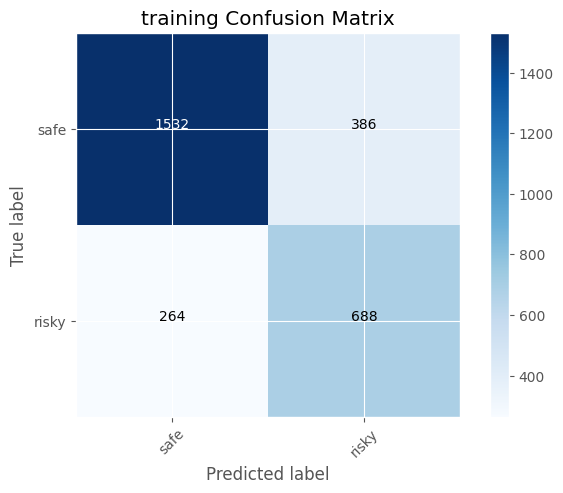

Confusion matrix, without normalization
[[1456  303]
 [ 241  501]]


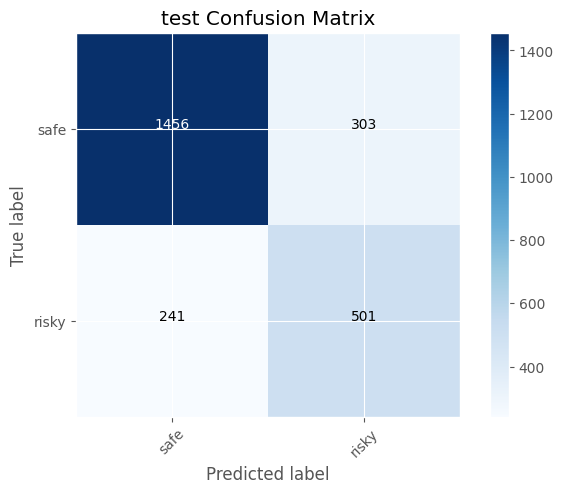

In [25]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import itertools
from sklearn.metrics import confusion_matrix
import tensorflow as tf

plt.style.use('ggplot')

def plot_history(history, model):
    # 改從 history.history 取出實際紀錄的指標，避開新版 model.metrics_names 內部的不可見變數 (如 compile_metrics)
    metrics = [k for k in history.history.keys() if not k.startswith('val_')]
    
    # 動態計算子圖表的列數，2欄
    rows = (len(metrics) + 1) // 2
    plt.figure(figsize=(12, 4 * rows))
    
    for n, metric in enumerate(metrics):
        name = metric.replace("_"," ").capitalize()
        
        plt.subplot(rows, 2, n+1)
        plt.plot(history.epoch,  history.history[metric], color='b', label='Train')
        # 確保有 val_ 的時候才畫出驗證集的線
        if 'val_'+metric in history.history:
            plt.plot(history.epoch, history.history['val_'+metric],
                 color='r', linestyle="--", label='Val')
        plt.xlabel('Epoch')
        plt.ylabel(name)
        plt.legend()
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(cm, classes,
                        normalize=False,
                        title='Confusion matrix',
                        cmap=plt.cm.Blues):
    plt.figure()
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

# 劃出訓練歷史
plot_history(history, model)

cm_plot_labels = ['safe','risky']

# ==========================================
# 進階實作 1: 動態尋找最佳閾值 (Dynamic Thresholding)
# 根據 F1-score 最大化的原則，讓模型自動算出最棒的切點，取代手動設定 0.4
# ==========================================
from sklearn.metrics import precision_recall_curve

# 先產生所有樣本的預測機率
y_pred_prob_train = model.predict([X_train, X_train_static]).ravel()
y_pred_prob_test = model.predict([X_test, X_test_static]).ravel()

# 使用測試集的 PR 曲線來尋找最佳閾值
precision_arr, recall_arr, thresholds_arr = precision_recall_curve(y_test, y_pred_prob_test)
# 計算每一個 threshold 對應的 F1-score
fscore = (2 * precision_arr * recall_arr) / (precision_arr + recall_arr + 1e-8)
best_idx = np.argmax(fscore)
opt_threshold = thresholds_arr[best_idx]

print(f"\n🔥 [自動最佳化] 演算法計算出能達到最高 F1-score 的最佳 Threshold 為: {opt_threshold:.4f}")
threshold = opt_threshold

# 套用動態閾值來判斷 Safe 或 Risky
y_pred_train = (y_pred_prob_train > threshold).astype("int32")
con_mat = tf.math.confusion_matrix(labels=y_train, predictions=y_pred_train).numpy()
cm_train = confusion_matrix(y_true=y_train, y_pred=y_pred_train)
plot_confusion_matrix(cm=cm_train, classes=cm_plot_labels, title='training Confusion Matrix')

y_pred_test = (y_pred_prob_test > threshold).astype("int32")
con_mat_test = tf.math.confusion_matrix(labels=y_test, predictions=y_pred_test).numpy()
cm_test = confusion_matrix(y_true=y_test, y_pred=y_pred_test)
plot_confusion_matrix(cm=cm_test, classes=cm_plot_labels, title='test Confusion Matrix')

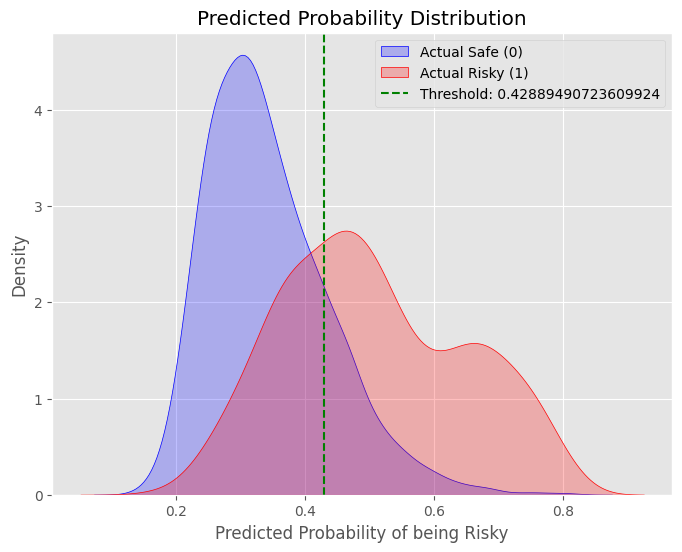

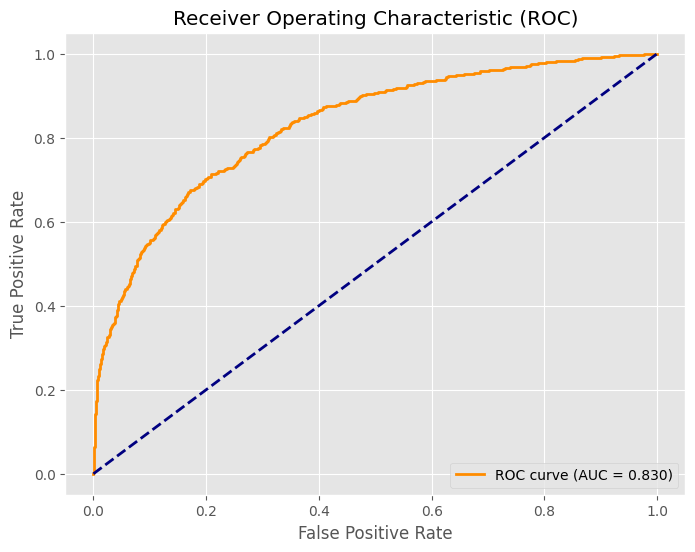

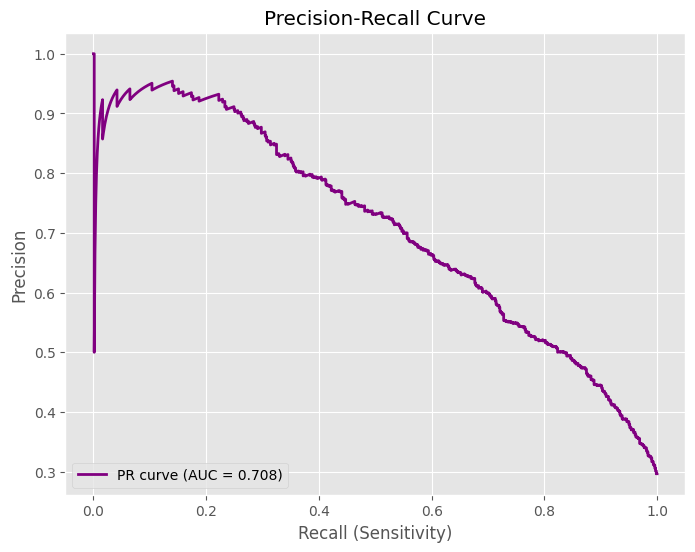


---
### 📊 綜合評估報告 (Classification Report)

|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| Safe (0)     |    0.857985 | 0.827743 |   0.842593 |      1759 |
| Risky (1)    |    0.623134 | 0.675202 |   0.648124 |       742 |
| accuracy     |    0.782487 | 0.782487 |   0.782487 |         0 |
| macro avg    |    0.74056  | 0.751473 |   0.745358 |      2501 |
| weighted avg |    0.788309 | 0.782487 |   0.784897 |      2501 |

**◆ 說明：**
* **Precision (精準率)**：模型說是 Risky 的人當中，實際真的是 Risky 的比例。
* **Recall (召回率)**：實際是 Risky 的人當中，模型成功挑出多少比例。
* **F1-score**：Precision 與 Recall 的綜合平均，越高越好。
---


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 772ms/step


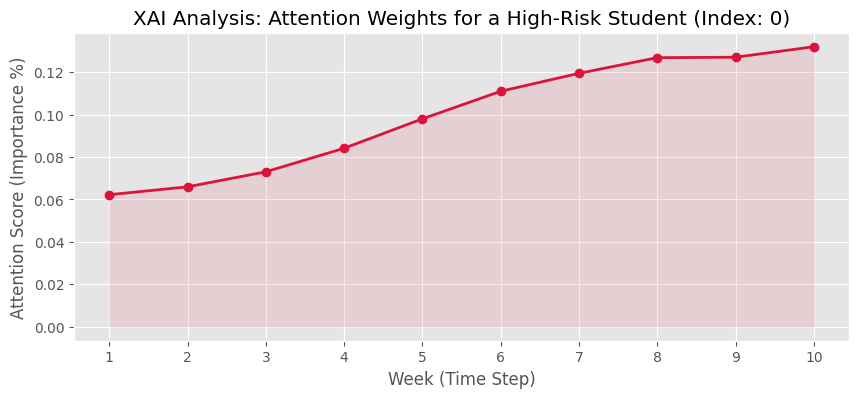


💡 【輔導員的解釋看板】
XAI 解釋：模型抓到這個學生有高退學風險，最核心的判斷依據落在了「第 10 週」的異常行為狀態！
👉 我們可以把這張圖放進 Dashboard，讓輔導小老師知道該去查學生第幾週到底發生了什麼事。


In [27]:
from sklearn.metrics import classification_report, roc_curve, auc, precision_recall_curve
import seaborn as sns
from IPython.display import display, Markdown
import pandas as pd

# 注意：前面已經取得 y_pred_prob_test 了，這裡註解掉以免重複執行
# y_pred_prob_test = model.predict([X_test, X_test_static]).ravel()

# ==========================================
# 圖表 A：預測機率分佈圖 (KDE Plot)
# 目的：觀察模型是否能把「安全(0)」與「危險(1)」的學生機率拉開
# ==========================================
plt.figure(figsize=(8, 6))
sns.kdeplot(y_pred_prob_test[y_test == 0], color='blue', fill=True, label='Actual Safe (0)')
sns.kdeplot(y_pred_prob_test[y_test == 1], color='red', fill=True, label='Actual Risky (1)')
plt.title('Predicted Probability Distribution')
plt.xlabel('Predicted Probability of being Risky')
plt.ylabel('Density')
plt.axvline(x=threshold, color='green', linestyle='--', label=f'Threshold: {threshold}')
plt.legend()
plt.show()

# ==========================================
# 圖表 B：ROC 曲線 (ROC Curve)
# 目的：觀察偽陽性與真陽性的權衡，AUC 越接近 1 越好
# ==========================================
plt.figure(figsize=(8, 6))
fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_prob_test)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Receiver Operating Characteristic (ROC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

# ==========================================
# 圖表 C：PR 曲線 (Precision-Recall Curve)
# 目的：對於資料不平衡的情況，這張圖更能展現抓出 Risky 學生的實力
# ==========================================
plt.figure(figsize=(8, 6))
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_pred_prob_test)
pr_auc = auc(recall, precision)
plt.plot(recall, precision, color='purple', lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision')
plt.legend(loc="lower left")
plt.show()

# ==========================================
# 3. 輸出 Markdown 格式的綜合分類報告
# ==========================================
# 透過 output_dict=True 取得字典格式，轉為 DataFrame 後匯出 Markdown
report_dict = classification_report(y_test, y_pred_test, target_names=['Safe (0)', 'Risky (1)'], output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
report_df['support'] = report_df['support'].astype(int) # 讓 support 顯示為整數
report_md = report_df.to_markdown()

md_text = f"""
---
### 📊 綜合評估報告 (Classification Report)

{report_md}

**◆ 說明：**
* **Precision (精準率)**：模型說是 Risky 的人當中，實際真的是 Risky 的比例。
* **Recall (召回率)**：實際是 Risky 的人當中，模型成功挑出多少比例。
* **F1-score**：Precision 與 Recall 的綜合平均，越高越好。
---
"""

display(Markdown(md_text))

# ==========================================
# 進階實作 2: 可解釋性 AI (XAI) - 取出注意力機制的權度並畫圖
# 讓輔導員一眼看出模型是根據哪幾週的異常表現發出的警報！
# ==========================================
from tensorflow.keras.models import Model

# 1. 抽取出 Attention 層作為新預測模型的輸出點
attention_layer_name = 'attention_weights'
attention_model = Model(inputs=model.input, outputs=model.get_layer(attention_layer_name).output)

# 2. 從測試集找出一位被模型成功抓出來的真實退學生 (True Positive)
true_positives = np.where((y_test == 1) & (y_pred_test == 1))[0]

if len(true_positives) > 0:
    # 隨機挑一位或拿第一位
    sample_idx = true_positives[0]
    sample_seq = X_test[sample_idx:sample_idx+1]
    sample_static = X_test_static[sample_idx:sample_idx+1]
    
    # 3. 取得他的 Attention 權重，並攤平為一維陣列 (flatten)
    att_weights = attention_model.predict([sample_seq, sample_static])[0].flatten()
    
    # 4. 畫圖 (X 軸是週數，Y 軸是權重占比)
    plt.figure(figsize=(10, 4))
    plt.plot(range(1, len(att_weights)+1), att_weights, marker='o', color='crimson', linewidth=2)
    plt.fill_between(range(1, len(att_weights)+1), att_weights, color='crimson', alpha=0.1)
    plt.title(f'XAI Analysis: Attention Weights for a High-Risk Student (Index: {sample_idx})')
    plt.xlabel('Week (Time Step)')
    plt.ylabel('Attention Score (Importance %)')
    plt.xticks(range(1, len(att_weights)+1))
    plt.grid(True)
    plt.show()
    
    print("\n💡 【輔導員的解釋看板】")
    highest_week = np.argmax(att_weights) + 1
    print(f"XAI 解釋：模型抓到這個學生有高退學風險，最核心的判斷依據落在了「第 {highest_week} 週」的異常行為狀態！")
    print("👉 我們可以把這張圖放進 Dashboard，讓輔導小老師知道該去查學生第幾週到底發生了什麼事。")
    
else:
    print("找不到 True Positive 樣本來畫 Attention 圖。")

In [28]:
# ==========================================
# 4. 儲存模型至本機端 (Save Model)
# ==========================================
import os

# 建立儲存模型的資料夾 (建立在專案根目錄下的 saved_models)
save_dir = os.path.join(PROJECT_DIR, 'saved_models')
os.makedirs(save_dir, exist_ok=True)

# 儲存模型為 Keras 推薦的 native 格式 (.keras)
model_path = os.path.join(save_dir, 'oulad_lstm_FFF_model.keras')
model.save(model_path)

print(f"\n✅ 模型已成功儲存至虛擬機：{model_path}")

# 若在 Google Colab 環境，觸發自動下載至本機電腦
try:
    from google.colab import files
    print("⏳ 偵測到 Google Colab 環境，正在準備下載模型至您的本機電腦...")
    files.download(model_path)
    print("✅ 下載請求已送出！")
    print("\n⚠️ 【如果檔案沒有自動下載怎麼辦？】")
    print("1. 您的瀏覽器可能阻擋了彈出式視窗，請看一下網址列右側有沒有「阻擋彈窗」的警告圖示。")
    print("2. 💡 最快的方法是直接從介面手動載下來：")
    print("   👉 點擊 Colab 畫面最左側的「資料夾」圖示 📁")
    print("   👉 打開 `saved_models` 資料夾")
    print("   👉 停在 `oulad_lstm_FFF_model.keras` 檔案上，點擊右方三個點點 ⋮ 或右鍵")
    print("   👉 選擇「下載 (Download)」，就能直接把模型拉到您的電腦裡囉！")
except ImportError:
    print("ℹ️ 非 Google Colab 環境，模型已保存在上述路徑，請自行取用。")


✅ 模型已成功儲存至虛擬機：/content/saved_models/oulad_lstm_FFF_model.keras
⏳ 偵測到 Google Colab 環境，正在準備下載模型至您的本機電腦...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ 下載請求已送出！

⚠️ 【如果檔案沒有自動下載怎麼辦？】
1. 您的瀏覽器可能阻擋了彈出式視窗，請看一下網址列右側有沒有「阻擋彈窗」的警告圖示。
2. 💡 最快的方法是直接從介面手動載下來：
   👉 點擊 Colab 畫面最左側的「資料夾」圖示 📁
   👉 打開 `saved_models` 資料夾
   👉 停在 `oulad_lstm_FFF_model.keras` 檔案上，點擊右方三個點點 ⋮ 或右鍵
   👉 選擇「下載 (Download)」，就能直接把模型拉到您的電腦裡囉！
